# Luftkvalitet i Malmö – Dalaplan och Rådhuset

Data hämtas från Naturvårdsverkets REST-API för luftkvalitetsdata, som tillhandahålls av SMHI (datavärd för luft).

- **Dalaplan** är en *gaturumsstation*: den mäter mitt i trafikmiljön.
- **Rådhuset** är en *urban bakgrundsstation*: den mäter den allmänna luften i staden, på taket av Rådhuset.

Obs: senaste värdena är **realtidsdata** som ännu inte är kvalitetssäkrade.

In [1]:
import numpy as np
import requests
import pandas as pd
import matplotlib.pyplot as plt
from datetime import date, timedelta

pd.set_option("display.width", 200)

BASE = "https://datavardluft.smhi.se/52North/api"

# I API:et motsvarar varje "station-id" ett ämne på en plats
STATIONER = {
    "Dalaplan": [271, 272, 273, 274, 275, 276, 278, 412, 4131, 5750],
    "Rådhuset": [117, 118, 120, 121, 122, 123, 125, 4256, 5513, 5528],
}

AMNEN = {
    "NO2": "Kvävedioxid (NO2)",
    "NOX as NO2": "Kväveoxider (NOx)",
    "O3": "Ozon (O3)",
    "PM10": "Partiklar PM10",
    "PM2.5": "Partiklar PM2,5",
    "CO": "Kolmonoxid (CO)",
    "SO2": "Svaveldioxid (SO2)",
    "C6H6": "Bensen",
    "C6H5-CH3": "Toluen",
    "Black Carbon": "Sot (Black Carbon)",
    "UFPs": "Ultrafina partiklar",
}

def hamta(url, **params):
    svar = requests.get(url, params=params, timeout=30)
    svar.raise_for_status()
    return svar.json()

def till_svensk_tid(ms):
    tid = pd.to_datetime(ms, unit="ms", utc=True)
    if isinstance(tid, pd.Series):
        return tid.dt.tz_convert("Europe/Stockholm")
    return tid.tz_convert("Europe/Stockholm")

## 1. Stationerna

In [2]:
station = hamta(f"{BASE}/stations/276")
rad_dalaplan = {"plats": "Dalaplan", "typ": station["properties"]["classification"],
                "lon": station["geometry"]["coordinates"][0], "lat": station["geometry"]["coordinates"][1]}

station = hamta(f"{BASE}/stations/121")
rad_radhuset = {"plats": "Rådhuset", "typ": station["properties"]["classification"],
                "lon": station["geometry"]["coordinates"][0], "lat": station["geometry"]["coordinates"][1]}

pd.DataFrame([rad_dalaplan, rad_radhuset])

,plats,typ,lon,lat
0,Dalaplan,Gaturum,13.006230,55.584747
1,Rådhuset,Urban bakgrund,13.001964,55.606388


## 2. Hämta alla tidsserier för båda stationerna

Varje ämne kan ha flera tidsserier, till exempel när ett instrument har bytts ut. Vi hämtar alla och markerar vilka som fortfarande är aktiva. Det tar ungefär en halv minut.

In [3]:
rader = []
for plats, station_ids in STATIONER.items():
    for station_id in station_ids:
        try:
            station = hamta(f"{BASE}/stations/{station_id}")
        except Exception as e:
            print(f"Kunde inte hämta station {station_id}: {e}")
            continue
        for ts_id in station["properties"]["timeseries"]:
            try:
                ts = hamta(f"{BASE}/timeseries/{ts_id}")
            except Exception as e:
                print(f"Kunde inte hämta tidsserie {ts_id}: {e}")
                continue
            kod = ts["parameters"]["phenomenon"]["label"]
            rader.append({
                "plats": plats,
                "ämne_kod": kod,
                "ämne": AMNEN.get(kod, kod),
                "tidsserie_id": ts_id,
                "enhet": ts.get("uom"),
                "första_mätning": till_svensk_tid(ts["firstValue"]["timestamp"]) if ts.get("firstValue") else None,
                "senaste_mätning": till_svensk_tid(ts["lastValue"]["timestamp"]) if ts.get("lastValue") else None,
                "senaste_värde": ts["lastValue"]["value"] if ts.get("lastValue") else None,
            })

tidsserier = pd.DataFrame(rader)

# En tidsserie räknas som aktiv om den har data från de senaste två dygnen
grans = pd.Timestamp.now(tz="Europe/Stockholm") - pd.Timedelta(days=2)
tidsserier["aktiv"] = tidsserier["senaste_mätning"] > grans

print(f"{len(tidsserier)} tidsserier totalt, varav {tidsserier['aktiv'].sum()} aktiva")

32 tidsserier totalt, varav 14 aktiva


## 3. Vilka ämnen mäts idag på respektive station?

In [4]:
aktiva = tidsserier[tidsserier["aktiv"]].copy()

oversikt = pd.crosstab(aktiva["ämne"], aktiva["plats"]).astype(bool).replace({True: "✓", False: ""})
oversikt

plats,Dalaplan,Rådhuset
ämne,,
Bensen,✓,
Kolmonoxid (CO),✓,
Kvävedioxid (NO2),✓,✓
Ozon (O3),✓,✓
Partiklar PM10,✓,✓
"Partiklar PM2,5",✓,✓
Sot (Black Carbon),✓,✓
Svaveldioxid (SO2),,✓
Ultrafina partiklar,✓,


## 4. Senaste mätningen

In [5]:
senaste = aktiva[["plats", "ämne", "senaste_värde", "enhet", "senaste_mätning"]].copy()
senaste["senaste_mätning"] = senaste["senaste_mätning"].dt.strftime("%Y-%m-%d %H:%M")
senaste.sort_values(["ämne", "plats"]).reset_index(drop=True)

,plats,ämne,senaste_värde,enhet,senaste_mätning
0,Dalaplan,Bensen,0.63,µg/m3,2026-10-02 10:00
1,Dalaplan,Kolmonoxid (CO),0.78,µg/m3,2026-10-02 10:00
2,Dalaplan,Kvävedioxid (NO2),22.90,µg/m3,2026-10-02 09:00
3,Rådhuset,Kvävedioxid (NO2),10.20,µg/m3,2026-10-02 10:00
4,Dalaplan,Ozon (O3),34.10,µg/m3,2026-10-02 10:00
5,Rådhuset,Ozon (O3),35.40,µg/m3,2026-10-02 10:00
6,Dalaplan,Partiklar PM10,5.97,µg/m3,2026-10-02 10:00
7,Rådhuset,Partiklar PM10,5.86,µg/m3,2026-10-02 10:00
8,Dalaplan,"Partiklar PM2,5",4.12,µg/m3,2026-10-02 10:00
9,Rådhuset,"Partiklar PM2,5",3.88,µg/m3,2026-10-02 10:00


Samma sak som en jämförelse sida vid sida:

In [6]:
aktiva.pivot_table(index="ämne", columns="plats", values="senaste_värde").round(1)

plats,Dalaplan,Rådhuset
ämne,,
Bensen,0.6,NaN
Kolmonoxid (CO),0.8,NaN
Kvävedioxid (NO2),22.9,10.2
Ozon (O3),34.1,35.4
Partiklar PM10,6.0,5.9
"Partiklar PM2,5",4.1,3.9
Sot (Black Carbon),0.2,0.3
Svaveldioxid (SO2),NaN,0.5
Ultrafina partiklar,6254.8,NaN


## 5. Hur lång historik finns?

Första mätningen i den *aktiva* tidsserien. För partiklar kan det finnas äldre tidsserier från tidigare instrument som går att skarva ihop.

In [7]:
historik = aktiva[["plats", "ämne", "första_mätning"]].copy()
historik["år_med_data"] = ((pd.Timestamp.now(tz="Europe/Stockholm") - historik["första_mätning"]).dt.days / 365.25).round(1)
historik["första_mätning"] = historik["första_mätning"].dt.strftime("%Y-%m-%d")
historik.sort_values(["ämne", "plats"]).reset_index(drop=True)

,plats,ämne,första_mätning,år_med_data
0,Dalaplan,Bensen,2006-01-01,20.8
1,Dalaplan,Kolmonoxid (CO),2012-02-03,14.7
2,Dalaplan,Kvävedioxid (NO2),1999-11-05,26.9
3,Rådhuset,Kvävedioxid (NO2),1998-01-01,28.8
4,Dalaplan,Ozon (O3),2006-01-01,20.8
5,Rådhuset,Ozon (O3),1998-01-01,28.8
6,Dalaplan,Partiklar PM10,2023-01-01,3.8
7,Rådhuset,Partiklar PM10,2022-01-01,4.8
8,Dalaplan,"Partiklar PM2,5",2023-05-26,3.4
9,Rådhuset,"Partiklar PM2,5",2022-01-01,4.8


## 6. Kvävedioxid senaste veckan 

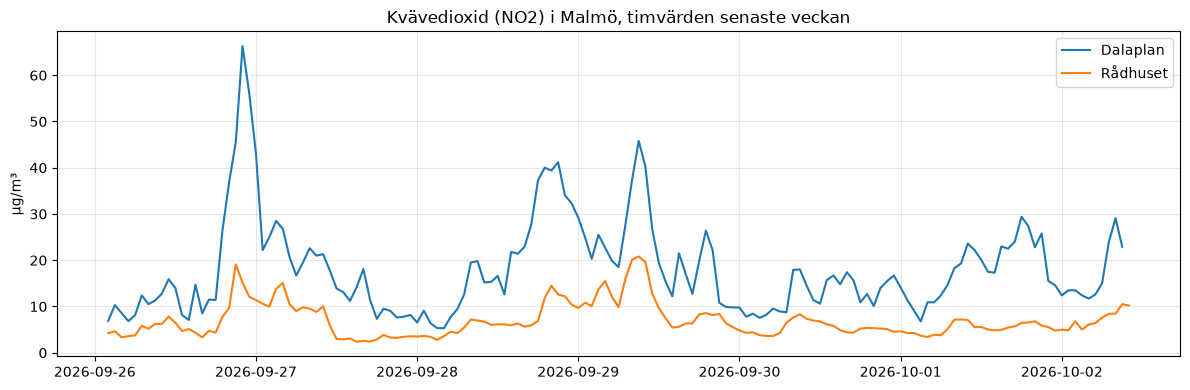

In [8]:
slut = (date.today() + timedelta(days=1)).isoformat()
no2 = aktiva[aktiva["ämne_kod"] == "NO2"]

fig, ax = plt.subplots(figsize=(12, 4))
for _, rad in no2.iterrows():
    data = hamta(f"{BASE}/timeseries/{rad['tidsserie_id']}/getData", timespan=f"P7D/{slut}")
    df = pd.DataFrame(data["values"])
    df["tid"] = till_svensk_tid(df["timestamp"])
    ax.plot(df["tid"], df["value"], label=rad["plats"])

ax.set_title("Kvävedioxid (NO2) i Malmö, timvärden senaste veckan")
ax.set_ylabel("µg/m³")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

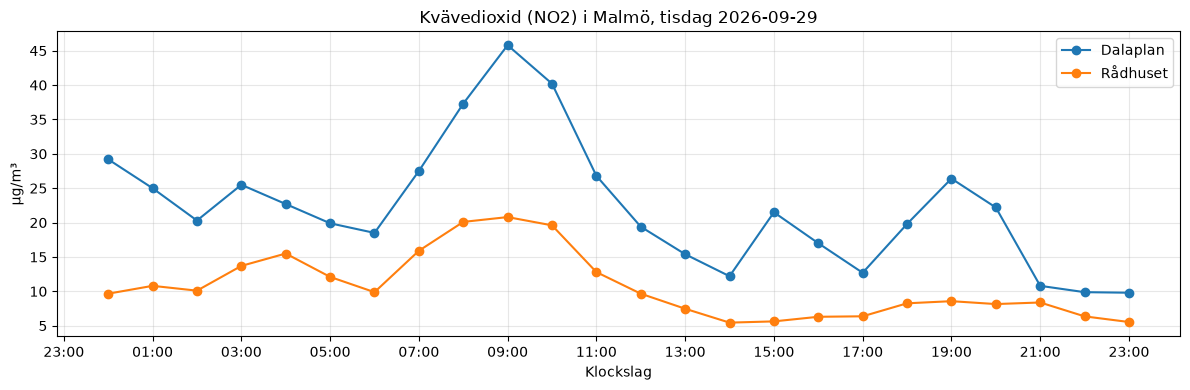

In [9]:
import matplotlib.dates as mdates

# Hitta förra tisdagen (weekday: måndag = 0, tisdag = 1)
idag = date.today()
dagar_sedan = (idag.weekday() - 1) % 7 or 7
tisdag = idag - timedelta(days=dagar_sedan)

# Hämta några dagar runt tisdagen och filtrera sedan ut dygnet i svensk tid,
# så att vi slipper krångel med UTC vid dygnsgränserna
slut = (tisdag + timedelta(days=2)).isoformat()

fig, ax = plt.subplots(figsize=(12, 4))
for _, rad in no2.iterrows():
    data = hamta(f"{BASE}/timeseries/{rad['tidsserie_id']}/getData", timespan=f"P4D/{slut}")
    df = pd.DataFrame(data["values"])
    df["tid"] = till_svensk_tid(df["timestamp"])
    df = df[df["tid"].dt.date == tisdag]
    ax.plot(df["tid"], df["value"], marker="o", label=rad["plats"])

ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz="Europe/Stockholm"))
ax.set_title(f"Kvävedioxid (NO2) i Malmö, tisdag {tisdag.isoformat()}")
ax.set_xlabel("Klockslag")
ax.set_ylabel("µg/m³")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

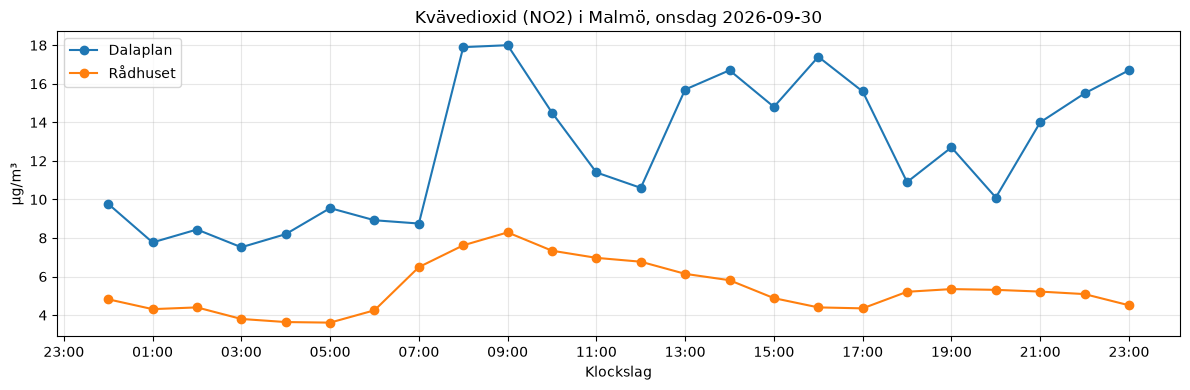

In [10]:
def rita_dygn(dag):
    slut = (dag + timedelta(days=2)).isoformat()

    fig, ax = plt.subplots(figsize=(12, 4))
    for _, rad in no2.iterrows():
        data = hamta(f"{BASE}/timeseries/{rad['tidsserie_id']}/getData", timespan=f"P4D/{slut}")
        df = pd.DataFrame(data["values"])
        df["tid"] = till_svensk_tid(df["timestamp"])
        df = df[df["tid"].dt.date == dag]
        ax.plot(df["tid"], df["value"], marker="o", label=rad["plats"])

    veckodagar = ["måndag", "tisdag", "onsdag", "torsdag", "fredag", "lördag", "söndag"]
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz="Europe/Stockholm"))
    ax.set_title(f"Kvävedioxid (NO2) i Malmö, {veckodagar[dag.weekday()]} {dag.isoformat()}")
    ax.set_xlabel("Klockslag")
    ax.set_ylabel("µg/m³")
    ax.legend()
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

Saturday = date.today() - timedelta(days=2)
rita_dygn(Saturday)

## 8. Väder och luftkvalitet

In [11]:
SMHI = "https://opendata-download-metobs.smhi.se/api/version/1.0"
DALAPLAN = (55.5847, 13.0062)

def narmaste_vaderstation(parameter):
    info = requests.get(f"{SMHI}/parameter/{parameter}.json", timeout=30).json()
    aktiva = [s for s in info["station"] if s.get("active")]
    bast = min(aktiva, key=lambda s: (s["latitude"] - DALAPLAN[0])**2 + (s["longitude"] - DALAPLAN[1])**2)
    return bast["key"], bast["name"]

def hamta_vader(parameter):
    station_id, namn = narmaste_vaderstation(parameter)
    url = f"{SMHI}/parameter/{parameter}/station/{station_id}/period/latest-months/data.json"
    data = requests.get(url, timeout=30).json()
    df = pd.DataFrame(data["value"])
    df["tid"] = till_svensk_tid(df["date"])
    df["value"] = pd.to_numeric(df["value"], errors="coerce")
    return df, namn

temperatur, temp_station = hamta_vader(1)
vind, vind_station = hamta_vader(4)
print(f"Temperatur från: {temp_station}")
print(f"Vind från: {vind_station}")

Temperatur från: Malmö A
Vind från: Malmö A


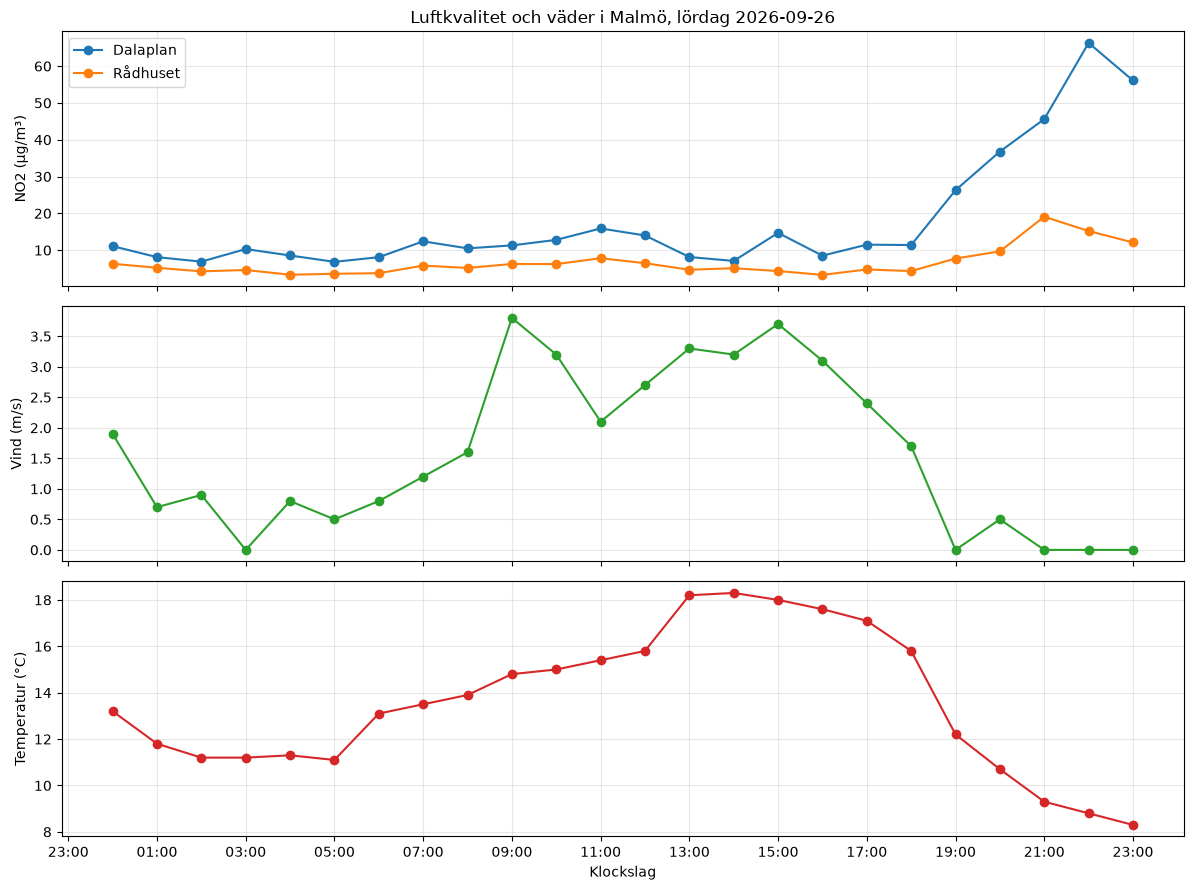

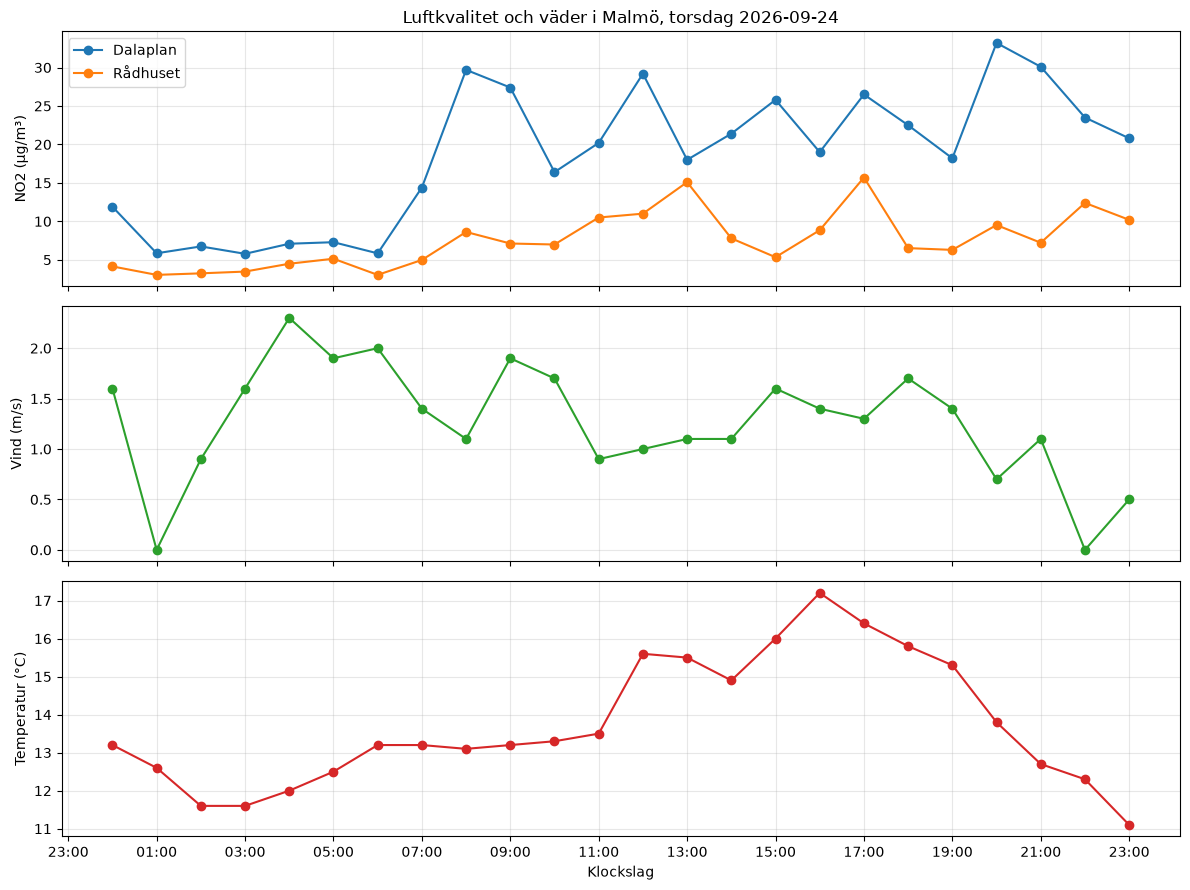

In [12]:
def rita_dygn_med_vader(dag):
    slut = (dag + timedelta(days=2)).isoformat()
    fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 9), sharex=True)

    for _, rad in no2.iterrows():
        data = hamta(f"{BASE}/timeseries/{rad['tidsserie_id']}/getData", timespan=f"P4D/{slut}")
        df = pd.DataFrame(data["values"])
        df["tid"] = till_svensk_tid(df["timestamp"])
        df = df[df["tid"].dt.date == dag]
        ax1.plot(df["tid"], df["value"], marker="o", label=rad["plats"])

    v = vind[vind["tid"].dt.date == dag]
    ax2.plot(v["tid"], v["value"], marker="o", color="tab:green")

    t = temperatur[temperatur["tid"].dt.date == dag]
    ax3.plot(t["tid"], t["value"], marker="o", color="tab:red")

    veckodagar = ["måndag", "tisdag", "onsdag", "torsdag", "fredag", "lördag", "söndag"]
    ax1.set_title(f"Luftkvalitet och väder i Malmö, {veckodagar[dag.weekday()]} {dag.isoformat()}")
    ax1.set_ylabel("NO2 (µg/m³)")
    ax1.legend()
    ax2.set_ylabel("Vind (m/s)")
    ax3.set_ylabel("Temperatur (°C)")
    ax3.set_xlabel("Klockslag")
    ax3.xaxis.set_major_locator(mdates.HourLocator(interval=2))
    ax3.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M", tz="Europe/Stockholm"))
    for ax in (ax1, ax2, ax3):
        ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

rita_dygn_med_vader(date(2026, 9, 26))
rita_dygn_med_vader(date(2026, 9, 24))

## Väderprognoser från SMHI

**Obs:** API:et ger bara den senaste prognosen, inte historiska prognoser. Om vi ska träna en modell korrekt så borde vi göra det på historiska prognoser. 

När modellen ska prediktera PM2.5 sex timmar framåt är det uppmätta vädret vid den framtida tidpunkten inte känt. Däremot finns väderprognoser, som är den information om framtida väder som faktiskt är tillgänglig vid prediktionstillfället.

Här undersöker vi SMHI:s prognosdata för Malmö: vilka parametrar som finns, hur tätt prognosen är uppdelad i tid, och hur den kan kopplas till timvärden för luftkvalitet.

**Datakälla:** SMHI:s öppna API för meteorologiska prognoser, SNOW1gv1 (ersatte det tidigare PMP3gv2 i mars 2026). API:et returnerar data från den gridpunkt som ligger närmast angivna koordinater. För Dalaplan ligger gridpunkten cirka 1,5 km nordost om stationen, fortfarande i centrala Malmö.

- API-dokumentation och parametrar: https://opendata.smhi.se/metfcst/snow1gv1/parameters
- Licens: CC BY 4.0, ange SMHI som källa.

### Viktigt att veta om datan

- **Tidsupplösning:** timvis de första cirka 2,5 dygnen, därefter var sjätte och var tolfte timme, totalt tio dagar. För en horisont på sex timmar räcker den timvisa delen.
- **Prognostidpunkt:** `referenceTime` anger vilken modellkörning prognosen bygger på. Den ska sparas om vi samlar in prognoser, så att vi vet vilken prognos som var tillgänglig vid varje tidpunkt.
- **Enheter:** temperatur i °C, vind i m/s, vindriktning i grader (varifrån det blåser), nederbörd i mm (kg/m²) per intervall.
- **Intervallparametrar:** nederbörd gäller tidsintervallet från `intervalParametersStartTime` till den angivna tiden, för de timvisa värdena alltså timmen före.
- **Saknade värden:** 9999 betyder saknat värde. I `precipitation_frozen_part` betyder -9 "ej tillämpligt". Båda behandlas som saknade.
- **Vindriktning som feature:** riktningen är cirkulär och omvandlas därför till sinus och cosinus.
- **Inga historiska prognoser:** API:et ger bara den senaste prognosen. 

In [13]:
PROGNOS_URL = ("https://opendata-download-metfcst.smhi.se/api/category/snow1g/"
               "version/1/geotype/point/lon/13.006/lat/55.585/data.json")

svar = requests.get(PROGNOS_URL, timeout=30).json()

# Visa övergripande information, t.ex. när prognosen gjordes
for nyckel, varde in svar.items():
    if nyckel != "timeSeries":
        print(f"{nyckel}: {varde}")

print(f"\nAntal tidpunkter i prognosen: {len(svar['timeSeries'])}")

createdTime: 2026-10-02T09:00:59Z
referenceTime: 2026-10-02T08:45:00Z
geometry: {'type': 'Point', 'coordinates': [13.025069, 55.592668]}

Antal tidpunkter i prognosen: 84


In [14]:
prognos = pd.json_normalize(svar["timeSeries"])
prognos.columns = [c.replace("data.", "") for c in prognos.columns]

prognos["tid"] = pd.to_datetime(prognos["time"], utc=True).dt.tz_convert("Europe/Stockholm")
prognos = prognos.drop(columns="time").set_index("tid")

# SMHI använder 9999 för saknade värden, bara i sifferkolumnerna
sifferkolumner = prognos.select_dtypes("number").columns
prognos[sifferkolumner] = prognos[sifferkolumner].replace(9999, float("nan"))

# -9 betyder "ej tillämpligt" i andelen fryst nederbörd, men kan vara en riktig temperatur
prognos["precipitation_frozen_part"] = prognos["precipitation_frozen_part"].replace(-9, float("nan"))

print("Parametrar i prognosen:")
print(list(prognos.columns))
prognos.head(12)

Parametrar i prognosen:
['intervalParametersStartTime', 'air_temperature', 'wind_from_direction', 'wind_speed', 'wind_speed_of_gust', 'relative_humidity', 'air_pressure_at_mean_sea_level', 'visibility_in_air', 'thunderstorm_probability', 'probability_of_frozen_precipitation', 'cloud_area_fraction', 'low_type_cloud_area_fraction', 'medium_type_cloud_area_fraction', 'high_type_cloud_area_fraction', 'cloud_base_altitude', 'cloud_top_altitude', 'precipitation_amount_mean_deterministic', 'precipitation_amount_mean', 'precipitation_amount_min', 'precipitation_amount_max', 'precipitation_amount_median', 'probability_of_precipitation', 'precipitation_frozen_part', 'predominant_precipitation_type_at_surface', 'symbol_code']


,intervalParametersStartTime,air_temperature,wind_from_direction,wind_speed,wind_speed_of_gust,relative_humidity,air_pressure_at_mean_sea_level,visibility_in_air,thunderstorm_probability,probability_of_frozen_precipitation,...,cloud_top_altitude,precipitation_amount_mean_deterministic,precipitation_amount_mean,precipitation_amount_min,precipitation_amount_max,precipitation_amount_median,probability_of_precipitation,precipitation_frozen_part,predominant_precipitation_type_at_surface,symbol_code
tid,,,,,,,,,,,,,,,,,,,,,
2026-10-02 11:00:00+02:00,2026-10-02T08:00:00Z,16.3,295,3.3,6.3,87,1029.2,11.3,1,0.0,...,8369.0,0.0,0.1,0.3,0.9,0.0,27,0.0,1,6
2026-10-02 12:00:00+02:00,2026-10-02T09:00:00Z,16.1,294,3.7,6.9,90,1029.9,22.9,1,0.0,...,8364.0,0.1,0.4,0.3,0.4,0.3,93,0.0,1,18
2026-10-02 13:00:00+02:00,2026-10-02T10:00:00Z,16.0,299,3.1,6.7,91,1030.2,9.1,1,0.0,...,5523.0,0.1,0.4,0.4,0.6,0.4,90,0.0,1,18
2026-10-02 14:00:00+02:00,2026-10-02T11:00:00Z,16.1,315,3.1,6.0,89,1030.3,10.6,1,0.0,...,4547.0,0.1,0.3,0.2,0.7,0.2,70,0.0,1,18
2026-10-02 15:00:00+02:00,2026-10-02T12:00:00Z,16.3,310,3.3,6.5,86,1030.7,12.4,1,0.0,...,2953.0,0.0,0.1,0.2,0.8,0.0,23,0.0,1,6
2026-10-02 16:00:00+02:00,2026-10-02T13:00:00Z,16.3,327,2.5,6.4,84,1030.7,13.3,2,0.0,...,677.0,0.0,0.0,0.1,0.7,0.0,13,0.0,1,6
2026-10-02 17:00:00+02:00,2026-10-02T14:00:00Z,16.2,308,2.8,5.3,84,1031.0,13.4,2,0.0,...,677.0,0.0,0.0,0.1,0.2,0.0,10,0.0,1,6
2026-10-02 18:00:00+02:00,2026-10-02T15:00:00Z,16.0,294,2.9,5.6,84,1031.1,13.6,2,0.0,...,2323.0,0.0,0.0,0.0,0.0,0.0,0,NaN,0,6
2026-10-02 19:00:00+02:00,2026-10-02T16:00:00Z,15.3,305,2.7,5.3,86,1031.2,12.0,2,0.0,...,2323.0,0.0,0.0,0.0,0.0,0.0,0,NaN,0,6


### Prognosens tidsupplösning

Prognosen är uppdelad i tre delar:

- Timvis i ungefär två och ett halvt dygn (59 steg à en timme).
- Var sjätte timme i ytterligare ungefär tre och ett halvt dygn (14 steg), med ett enstaka steg på tre timmar i övergången.
- Var tolfte timme de sista fyra dygnen (8 steg).

Sammanlagt blir det drygt 240 timmar, alltså tio dagar.

För en prognoshorisont på sex timmar ligger all data vi behöver i den timvisa delen, så prognosen kan kopplas direkt till timvärden för PM2.5.

In [15]:
steg = prognos.index.to_series().diff().dropna()
print(steg.value_counts())

tid
0 days 01:00:00    60
0 days 06:00:00    14
0 days 12:00:00     8
0 days 03:00:00     1
Name: count, dtype: int64


### Hur vindriktning anges

Vindriktningen anges i grader medurs från norr och talar om **varifrån** det blåser, inte vart:

- 0° (eller 360°) = vind från norr
- 90° = från öster
- 180° = från söder
- 270° = från väster

Exempel: 300° ligger mellan väster (270°) och nordväst (315°), alltså vind från västnordväst. För Malmö betyder det att luften kommer in över Öresund, vilket ofta ger relativt ren luft. Det skiljer sig tydligt från den sydostliga vinden runt 130° i prognosen från 1 oktober 2026, där luften kommer in över land och kan föra med sig partiklar från kontinenten.

{'Temperatur (°C)': 'air_temperature', 'Vindhastighet (m/s)': 'wind_speed', 'Vindriktning (grader)': 'wind_from_direction', 'Nederbörd (mm/h)': 'probability_of_frozen_precipitation'}


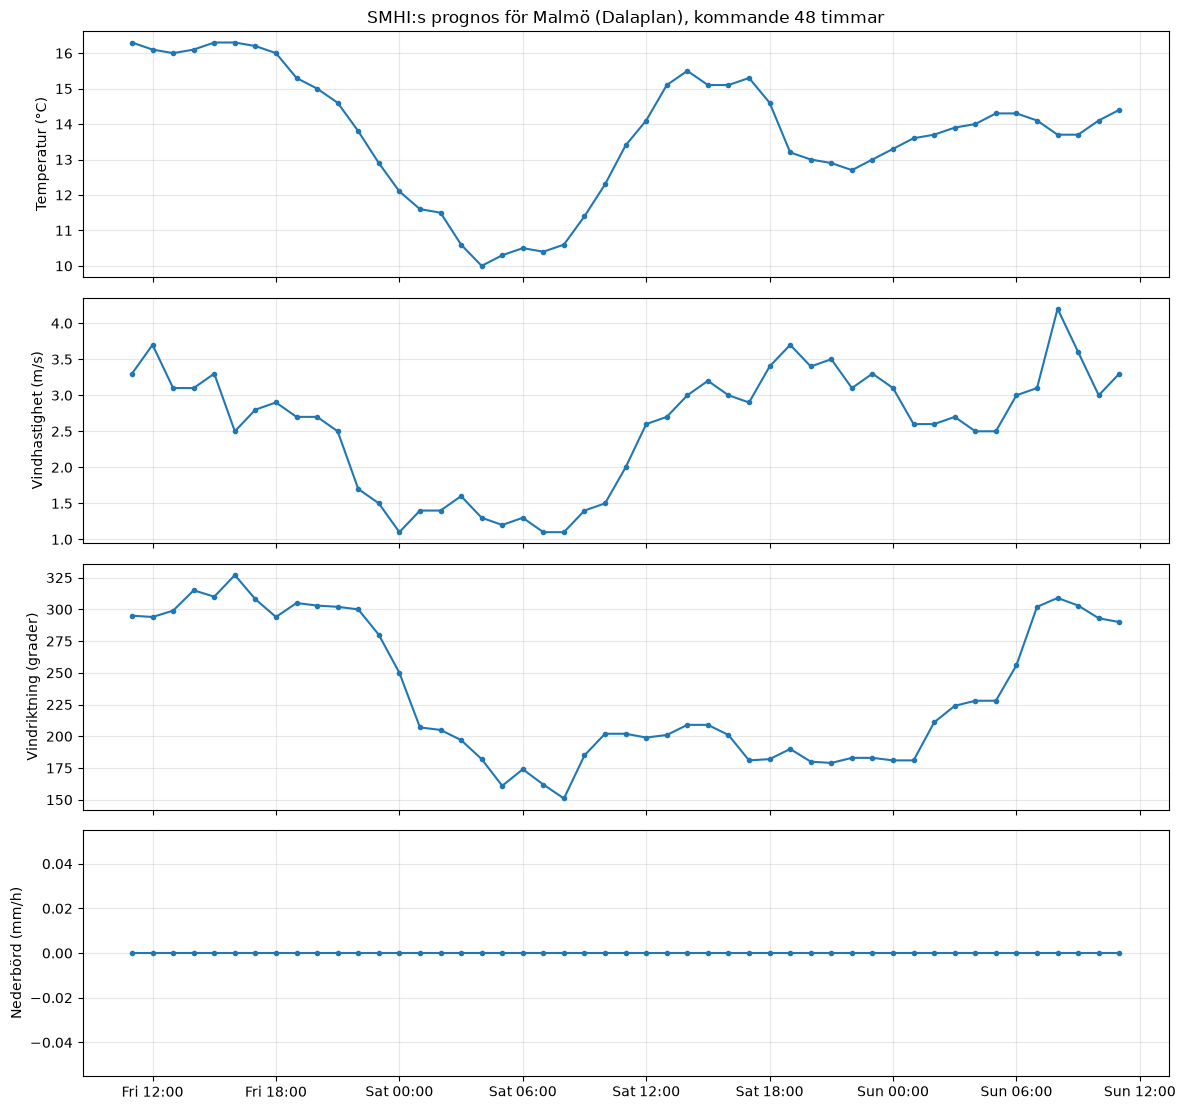

In [16]:
def hitta_kolumn(ord):
    traffar = [c for c in prognos.columns if ord in c]
    return traffar[0] if traffar else None

kolumner = {
    "Temperatur (°C)": hitta_kolumn("air_temperature"),
    "Vindhastighet (m/s)": hitta_kolumn("wind_speed"),
    "Vindriktning (grader)": hitta_kolumn("wind_from_direction"),
    "Nederbörd (mm/h)": hitta_kolumn("precipitation"),
}
kolumner = {namn: kol for namn, kol in kolumner.items() if kol}
print(kolumner)

narmaste = prognos[prognos.index <= prognos.index[0] + pd.Timedelta(hours=48)]

fig, axlar = plt.subplots(len(kolumner), 1, figsize=(12, 2.8 * len(kolumner)), sharex=True)
for ax, (namn, kol) in zip(axlar, kolumner.items()):
    ax.plot(narmaste.index, narmaste[kol], marker="o", markersize=3)
    ax.set_ylabel(namn)
    ax.grid(alpha=0.3)

axlar[0].set_title("SMHI:s prognos för Malmö (Dalaplan), kommande 48 timmar")
axlar[-1].xaxis.set_major_formatter(mdates.DateFormatter("%a %H:%M", tz="Europe/Stockholm"))
plt.tight_layout()
plt.show()

### Vindriktning som features

Vindriktning är cirkulär: 359° och 1° är nästan samma riktning men ser ut att ligga långt isär för en modell. Därför delas riktningen upp i sinus och cosinus, så att närliggande riktningar också får närliggande värden.

In [17]:
radianer = np.deg2rad(prognos["wind_from_direction"])
prognos["vind_sin"] = np.sin(radianer)
prognos["vind_cos"] = np.cos(radianer)

prognos[["wind_from_direction", "vind_sin", "vind_cos"]].head(12)

,wind_from_direction,vind_sin,vind_cos
tid,,,
2026-10-02 11:00:00+02:00,295,-0.906308,0.422618
2026-10-02 12:00:00+02:00,294,-0.913545,0.406737
2026-10-02 13:00:00+02:00,299,-0.874620,0.484810
2026-10-02 14:00:00+02:00,315,-0.707107,0.707107
2026-10-02 15:00:00+02:00,310,-0.766044,0.642788
2026-10-02 16:00:00+02:00,327,-0.544639,0.838671
2026-10-02 17:00:00+02:00,308,-0.788011,0.615661
2026-10-02 18:00:00+02:00,294,-0.913545,0.406737
2026-10-02 19:00:00+02:00,305,-0.819152,0.573576


### Undersöker andra stationer som ligger nära Malmö A väderstation

In [18]:
import numpy as np

def avstand_km(lat1, lon1, lat2, lon2):
    # Enkel approximation som räcker på korta avstånd
    dy = (lat2 - lat1) * 111
    dx = (lon2 - lon1) * 111 * np.cos(np.deg2rad(lat1))
    return np.sqrt(dx**2 + dy**2)

alla_stationer = requests.get(f"{BASE}/stations", timeout=60).json()

luftstationer = pd.DataFrame([{
    "id": s["id"],
    "namn": s["properties"]["label"],
    "typ": s["properties"].get("classification"),
    "lon": s["geometry"]["coordinates"][0],
    "lat": s["geometry"]["coordinates"][1],
} for s in alla_stationer])

malmo_stationer = luftstationer[luftstationer["namn"].str.startswith("Malmö")].drop_duplicates("namn").copy()
malmo_stationer["km_till_dalaplan"] = avstand_km(55.584747, 13.006230, malmo_stationer["lat"], malmo_stationer["lon"])
malmo_stationer["km_till_malmo_a"] = avstand_km(55.5715, 13.0708, malmo_stationer["lat"], malmo_stationer["lon"])

malmo_stationer.sort_values("km_till_malmo_a")[["namn", "typ", "km_till_dalaplan", "km_till_malmo_a"]].round(1)

,namn,typ,km_till_dalaplan,km_till_malmo_a
2403,Malmö Rosengård,Urban bakgrund,2.6,2.1
2370,Malmö Fosie,Urban bakgrund,3.1,2.7
2395,Malmö Lundavägen,Gaturum,1.4,2.9
2423,Malmö Wowragården,Gaturum,7.1,3.3
2360,Malmö Dalaplan 5B,Gaturum,0.0,4.3
2350,Malmö Dalaplan,Gaturum,0.0,4.3
2419,Malmö Vattenverksvägen,Gaturum,3.6,4.3
2347,Malmö Bergsgatan,Gaturum,1.0,4.7
2399,Malmö Pilgatan,Gaturum,2.6,4.8
2385,Malmö Föreningsgatan 28,Gaturum,1.6,4.9


### Kollar om någon av stationerna nära Malmlö A mäter PM2.5

In [19]:
kandidater = luftstationer[luftstationer["namn"].isin(["Malmö Rosengård", "Malmö Fosie"])]

rader = []
for _, station in kandidater.iterrows():
    info = requests.get(f"{BASE}/stations/{station['id']}", timeout=30).json()
    for ts_id, ts_info in info["properties"]["timeseries"].items():
        if ts_info["phenomenon"]["label"] != "PM2.5":
            continue
        ts = requests.get(f"{BASE}/timeseries/{ts_id}", timeout=30).json()
        rader.append({
            "station": station["namn"],
            "tidsserie_id": ts_id,
            "första": till_svensk_tid(ts["firstValue"]["timestamp"]) if ts.get("firstValue") else None,
            "senaste": till_svensk_tid(ts["lastValue"]["timestamp"]) if ts.get("lastValue") else None,
        })

pd.DataFrame(rader)

""


## testar att hämta data

In [20]:
import time

def hamta_pm25(start, slut, tidsserie_id=6247):
    """Hämtar PM2.5 en månad i taget. Datumen tolkas i svensk tid och slutdatumet ingår."""
    start_tid = pd.Timestamp(start, tz="Europe/Stockholm")
    slut_tid = pd.Timestamp(slut, tz="Europe/Stockholm") + pd.Timedelta(days=1) - pd.Timedelta(seconds=1)

    alla_varden = []
    for manad in pd.period_range(start_tid.tz_localize(None), slut_tid.tz_localize(None), freq="M"):
        fran = max(start_tid, manad.start_time.tz_localize("Europe/Stockholm"))
        till = min(slut_tid, manad.end_time.tz_localize("Europe/Stockholm"))
        timespan = (f"{fran.tz_convert('UTC'):%Y-%m-%dT%H:%M:%SZ}/"
                    f"{till.tz_convert('UTC'):%Y-%m-%dT%H:%M:%SZ}")

        print(f"Hämtar {manad}...", flush=True)
        svar = requests.get(f"{BASE}/timeseries/{tidsserie_id}/getData",
                            params={"timespan": timespan}, timeout=60)
        svar.raise_for_status()
        alla_varden.extend(svar.json()["values"])
        time.sleep(0.5)

    df = pd.DataFrame(alla_varden)
    df["tid"] = till_svensk_tid(df["timestamp"])
    return df.set_index("tid")[["value"]].rename(columns={"value": "pm25"})

pm25_2023 = hamta_pm25("2023-05-26", "2023-12-31")
pm25_2023.to_csv("pm25_dalaplan_2023.csv")
print(f"{len(pm25_2023)} rader")

Hämtar 2023-05...
Hämtar 2023-06...
Hämtar 2023-07...
Hämtar 2023-08...
Hämtar 2023-09...
Hämtar 2023-10...
Hämtar 2023-11...
Hämtar 2023-12...
5287 rader


In [21]:
import io

def hamta_vader_arkiv(parameter, station_id=52350):
    """Hämtar kvalitetskontrollerad arkivdata från SMHI för en parameter."""
    url = f"{SMHI}/parameter/{parameter}/station/{station_id}/period/corrected-archive/data.csv"
    text = requests.get(url, timeout=120).text

    # Hoppa över beskrivningen överst, tabellen börjar på raden som startar med "Datum"
    rader = text.splitlines()
    startrad = next(i for i, rad in enumerate(rader) if rad.startswith("Datum"))
    df = pd.read_csv(io.StringIO("\n".join(rader[startrad:])), sep=";", usecols=[0, 1, 2, 3])
    df.columns = ["datum", "tid_utc", "varde", "kvalitet"]

    df["tid"] = pd.to_datetime(df["datum"] + " " + df["tid_utc"], utc=True).dt.tz_convert("Europe/Stockholm")
    return df.set_index("tid")[["varde", "kvalitet"]]

parametrar = {
    "temperatur": 1,
    "vindhastighet": 4,
    "vindriktning": 3,
    "nederbord": 7,
}

vader_delar = {}
for namn, nummer in parametrar.items():
    print(f"Hämtar {namn}...", flush=True)
    try:
        data = hamta_vader_arkiv(nummer)
        vader_delar[namn] = data.loc["2023-05-26":"2023-12-31", "varde"]
    except Exception as e:
        print(f"  Fel för {namn}: {e}")

vader_2023 = pd.DataFrame(vader_delar)
vader_2023.to_csv("vader_malmo_a_2023.csv")
print(vader_2023.describe())
vader_2023.head()

Hämtar temperatur...
Hämtar vindhastighet...
Hämtar vindriktning...
Hämtar nederbord...
        temperatur  vindhastighet  vindriktning    nederbord
count  5279.000000    5278.000000   5278.000000  5035.000000
mean     12.559955       2.734975    182.575597     0.107150
std       7.166929       2.031603    104.660744     0.606802
min     -12.100000       0.000000      0.000000     0.000000
25%       7.400000       1.300000    100.000000     0.000000
50%      14.100000       2.400000    207.000000     0.000000
75%      17.800000       3.800000    269.000000     0.000000
max      28.100000      13.100000    360.000000    15.000000


,temperatur,vindhastighet,vindriktning,nederbord
tid,,,,
2023-05-26 00:00:00+02:00,11.2,4.5,318.0,0.0
2023-05-26 01:00:00+02:00,10.4,4.1,308.0,0.0
2023-05-26 02:00:00+02:00,9.8,4.1,308.0,0.0
2023-05-26 03:00:00+02:00,9.5,4.6,304.0,0.0
2023-05-26 04:00:00+02:00,9.3,4.0,302.0,0.0


## PM2.5 och väder senaste 24 timmarna

In [23]:
from datetime import datetime, timezone
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

LUFT_API = "https://datavardluft.smhi.se/52North/api"
VADER_API = "https://opendata-download-metobs.smhi.se/api/version/1.0"
PM25 = {"PM2.5 Dalaplan": 6247, "PM2.5 Rådhuset": 6161}
VADER = {"Temp (°C)": 1, "Vind (m/s)": 4, "Fukt (%)": 6}
MALMO_A = 52350

def hamta_pm25_24h(tidsserie_id):
    slut = datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ")
    svar = requests.get(f"{LUFT_API}/timeseries/{tidsserie_id}/getData",
                        params={"timespan": f"PT24H/{slut}"}, timeout=60)
    svar.raise_for_status()
    df = pd.DataFrame(svar.json()["values"])
    tid = pd.to_datetime(df["timestamp"], unit="ms", utc=True).dt.tz_convert("Europe/Stockholm")
    return pd.Series(df["value"].values, index=tid)

def hamta_vader_24h(parameter):
    url = f"{VADER_API}/parameter/{parameter}/station/{MALMO_A}/period/latest-day/data.json"
    svar = requests.get(url, timeout=60)
    svar.raise_for_status()
    df = pd.DataFrame(svar.json()["value"])
    tid = pd.to_datetime(df["date"], unit="ms", utc=True).dt.tz_convert("Europe/Stockholm")
    return pd.Series(pd.to_numeric(df["value"], errors="coerce").values, index=tid)

kolumner = {}
for namn, ts_id in PM25.items():
    kolumner[namn] = hamta_pm25_24h(ts_id)
for namn, parameter in VADER.items():
    try:
        kolumner[namn] = hamta_vader_24h(parameter)
    except Exception as e:
        print(f"Kunde inte hämta {namn}: {e}")

nu = pd.DataFrame(kolumner).sort_index()
print(f"Hämtat {datetime.now():%Y-%m-%d %H:%M}")

# Tabell där höga PM2.5-värden färgas mörkare
(nu.round(1)
   .style.format("{:.1f}", na_rep="–")
   .format_index(lambda t: t.strftime("%a %H:%M"))
   .background_gradient(subset=list(PM25), cmap="Oranges"))

Hämtat 2026-10-02 11:11


,PM2.5 Dalaplan,PM2.5 Rådhuset,Temp (°C),Vind (m/s),Fukt (%)
Thu 10:00,–,–,17.1,6.6,73.0
Thu 11:00,–,–,17.7,6.8,69.0
Thu 12:00,12.9,9.7,18.1,6.4,67.0
Thu 13:00,13.3,10.4,18.4,7.5,64.0
Thu 14:00,14.1,10.6,18.5,6.5,63.0
Thu 15:00,14.2,10.7,18.5,5.6,64.0
Thu 16:00,14.4,10.6,17.5,5.6,69.0
Thu 17:00,14.3,10.7,17.7,4.6,68.0
Thu 18:00,14.2,11.0,17.5,4.2,68.0
Thu 19:00,14.7,11.4,17.5,4.3,68.0


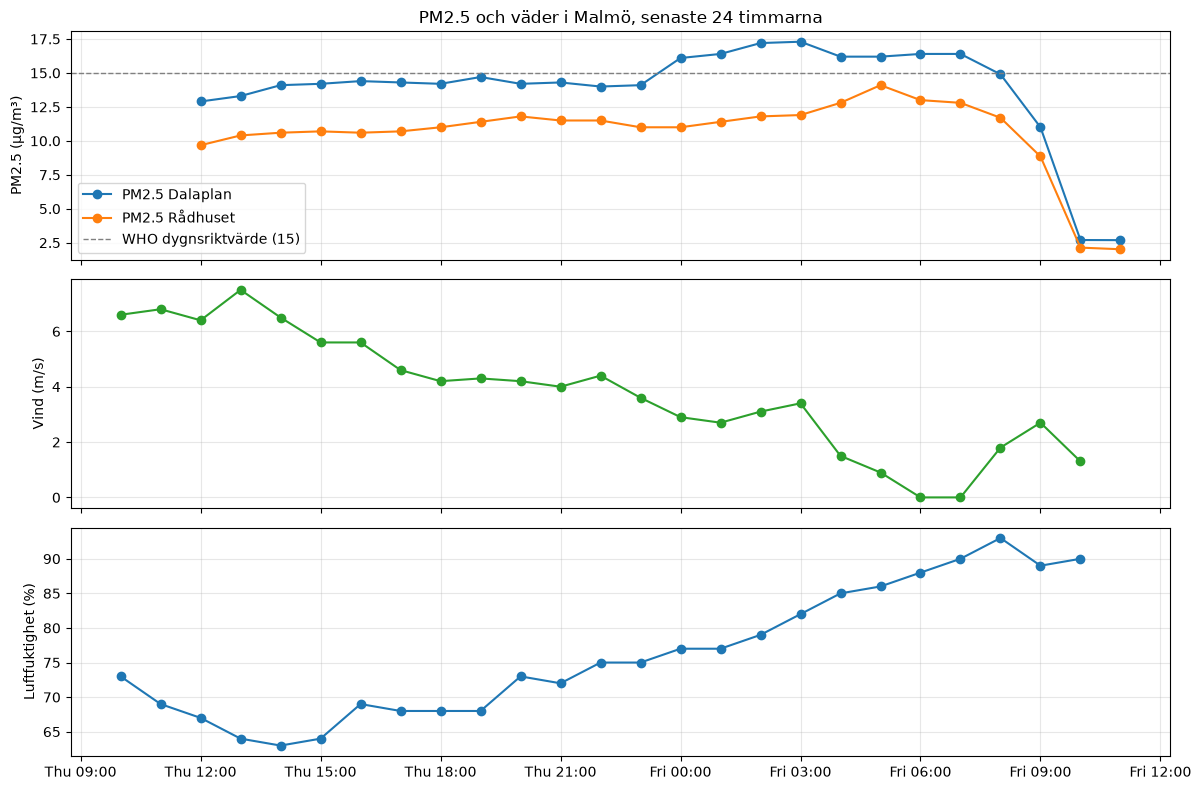

In [24]:
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

for namn in PM25:
    ax1.plot(nu.index, nu[namn], marker="o", label=namn)
ax1.axhline(15, color="grey", linestyle="--", linewidth=1, label="WHO dygnsriktvärde (15)")
ax1.set_ylabel("PM2.5 (µg/m³)")
ax1.legend()

if "Vind (m/s)" in nu:
    ax2.plot(nu.index, nu["Vind (m/s)"], marker="o", color="tab:green")
ax2.set_ylabel("Vind (m/s)")

if "Fukt (%)" in nu:
    ax3.plot(nu.index, nu["Fukt (%)"], marker="o", color="tab:blue")
ax3.set_ylabel("Luftfuktighet (%)")
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%a %H:%M", tz="Europe/Stockholm"))

for ax in (ax1, ax2, ax3):
    ax.grid(alpha=0.3)
ax1.set_title("PM2.5 och väder i Malmö, senaste 24 timmarna")
plt.tight_layout()
plt.show()